# 📊 RetailPulse: Exploratory Data Analysis
**Author:** Safae ERAJI  
This notebook downloads and merges two UCI Online Retail datasets, then performs exploratory data analysis.

In [2]:
# Loading Libraries
%matplotlib inline
import os
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Download Datasets
We will download the datasets to `../data/raw` if they don't already exist.

In [3]:
data_dir = '../data/raw'
os.makedirs(data_dir, exist_ok=True)

url1 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
url2 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx'

file1 = os.path.join(data_dir, 'Online_Retail.xlsx')
file2 = os.path.join(data_dir, 'Online_Retail_II.xlsx')

def download(url, filepath):
    if not os.path.exists(filepath):
        print(f"Downloading {url}\nTo: {filepath}...")
        urllib.request.urlretrieve(url, filepath)
        print("Download complete.\n")
    else:
        print(f"File already exists: {filepath}\n")

download(url1, file1)
download(url2, file2)

File already exists: ../data/raw\Online_Retail.xlsx

File already exists: ../data/raw\Online_Retail_II.xlsx



## 2. Load and Merge Datasets

In [4]:
print("Loading dataset 1 (2010-2011)...")
df1 = pd.read_excel(file1)

print("Loading dataset 2 (2009-2011)...")
df2 = pd.read_excel(file2)

# Ensure consistency in column names
df2.rename(columns={'Customer ID': 'CustomerID', 'Price': 'UnitPrice', 'Invoice': 'InvoiceNo'}, inplace=True)
df1.rename(columns={'Price': 'UnitPrice'}, inplace=True)

# Merge datasets
print("Merging datasets...")
df = pd.concat([df2, df1], ignore_index=True)

# Drop exact duplicates
df = df.drop_duplicates()

print(f"Merged dataset shape: {df.shape}")
display(df.head())

Loading dataset 1 (2010-2011)...
Loading dataset 2 (2009-2011)...
Merging datasets...
Merged dataset shape: (1033035, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Basic Data Exploration & Feature Engineering

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1033035 entries, 0 to 1067369
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1033035 non-null  object        
 1   StockCode    1033035 non-null  object        
 2   Description  1028760 non-null  object        
 3   Quantity     1033035 non-null  int64         
 4   InvoiceDate  1033035 non-null  datetime64[ns]
 5   UnitPrice    1033035 non-null  float64       
 6   CustomerID   797884 non-null   float64       
 7   Country      1033035 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 70.9+ MB


In [6]:
missing_values = df.isnull().sum()
missing_percentages = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentages})
display(missing_df[missing_df['Missing Values'] > 0])

,Missing Values,Percentage
Description,4275,0.413829
CustomerID,235151,22.763120


In [ ]:
# TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Extract temporal features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['YearMonth'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)

df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,YearMonth
count,1033035.0,1033035,1028760,1.033035e+06,1033035,1.033035e+06,797884.000000,1033035,1.033035e+06,1.033035e+06,1.033035e+06,1.033035e+06,1.033035e+06,1033035
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43,NaN,NaN,NaN,NaN,NaN,25
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,NaN,NaN,NaN,NaN,2011-11
freq,1114.0,5653,5740,NaN,NaN,NaN,NaN,948321,NaN,NaN,NaN,NaN,NaN,83343
mean,NaN,NaN,NaN,1.007689e+01,2011-01-03 14:30:06.998795008,4.613967e+00,15313.066077,NaN,1.825254e+01,2.010436e+03,7.393364e+00,1.534747e+01,1.302540e+01,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN,-1.684696e+05,2.009000e+03,1.000000e+00,1.000000e+00,6.000000e+00,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-05 11:38:00,1.250000e+00,13964.000000,NaN,3.750000e+00,2.010000e+03,4.000000e+00,8.000000e+00,1.100000e+01,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-09 13:34:00,2.100000e+00,15228.000000,NaN,9.920000e+00,2.010000e+03,8.000000e+00,1.500000e+01,1.300000e+01,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-27 13:17:00,4.150000e+00,16788.000000,NaN,1.770000e+01,2.011000e+03,1.100000e+01,2.300000e+01,1.500000e+01,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN,1.684696e+05,2.011000e+03,1.200000e+01,3.100000e+01,2.100000e+01,NaN


> 💡 **Data Insight:** Note that the negative values seen in the `min` rows above for Quantity and Price are **not errors**. They represent vital business information such as product returns, order cancellations, and manual accounting adjustments (like bad debt). 

## 4. Visualizations

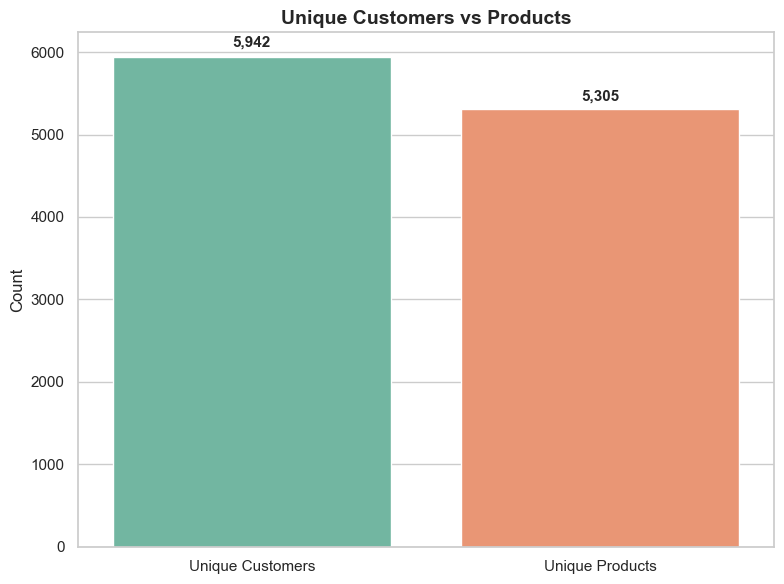

In [8]:
# --- Total Unique Customers vs Products ---
unique_customers = df['CustomerID'].nunique()
unique_products = df['StockCode'].nunique()

unique_counts = pd.DataFrame({
    'Category': ['Unique Customers', 'Unique Products'],
    'Count': [unique_customers, unique_products]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=unique_counts, x='Category', y='Count', hue='Category', palette='Set2', legend=False)
plt.title('Unique Customers vs Products', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('') 

for i, v in enumerate(unique_counts['Count']):
    plt.text(i, v + (v * 0.02), f'{v:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

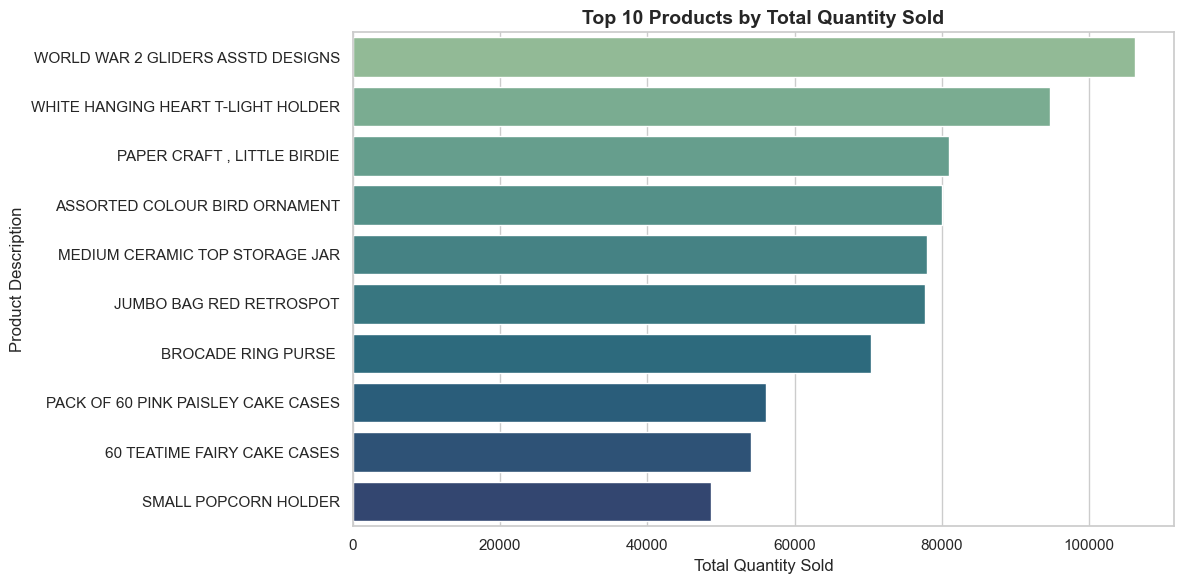

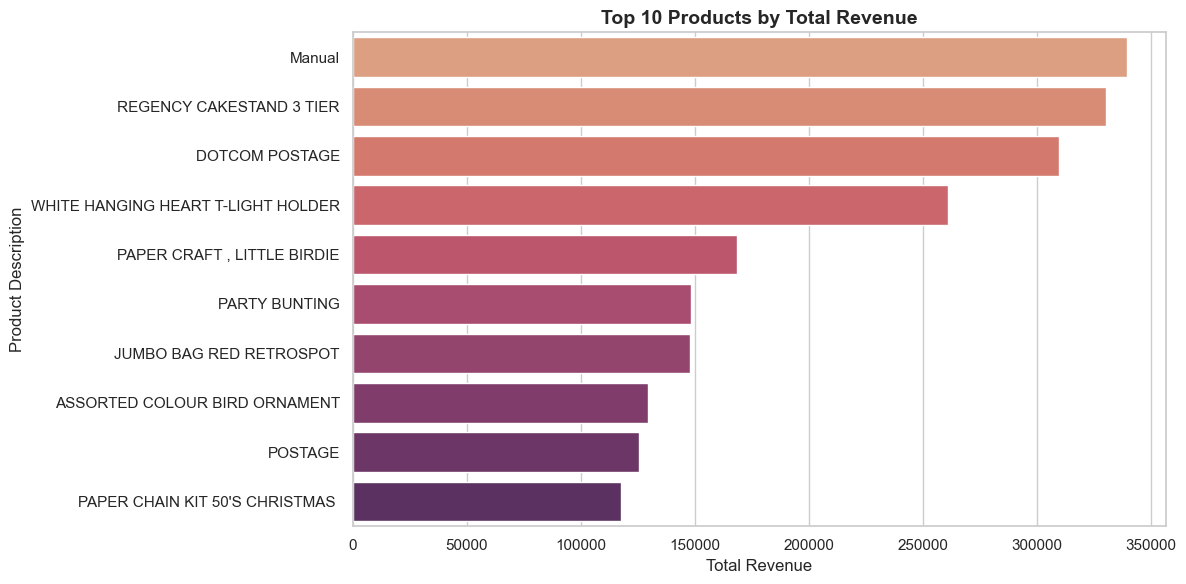

In [9]:
# --- Top 10 Products by Quantity & Revenue ---
valid_sales = df[df['Quantity'] > 0]

plt.figure(figsize=(12, 6))
top_products_qty = valid_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, hue=top_products_qty.index, palette='crest', legend=False)
plt.title('Top 10 Products by Total Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top_products_rev = valid_sales.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products_rev.values, y=top_products_rev.index, hue=top_products_rev.index, palette='flare', legend=False)
plt.title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

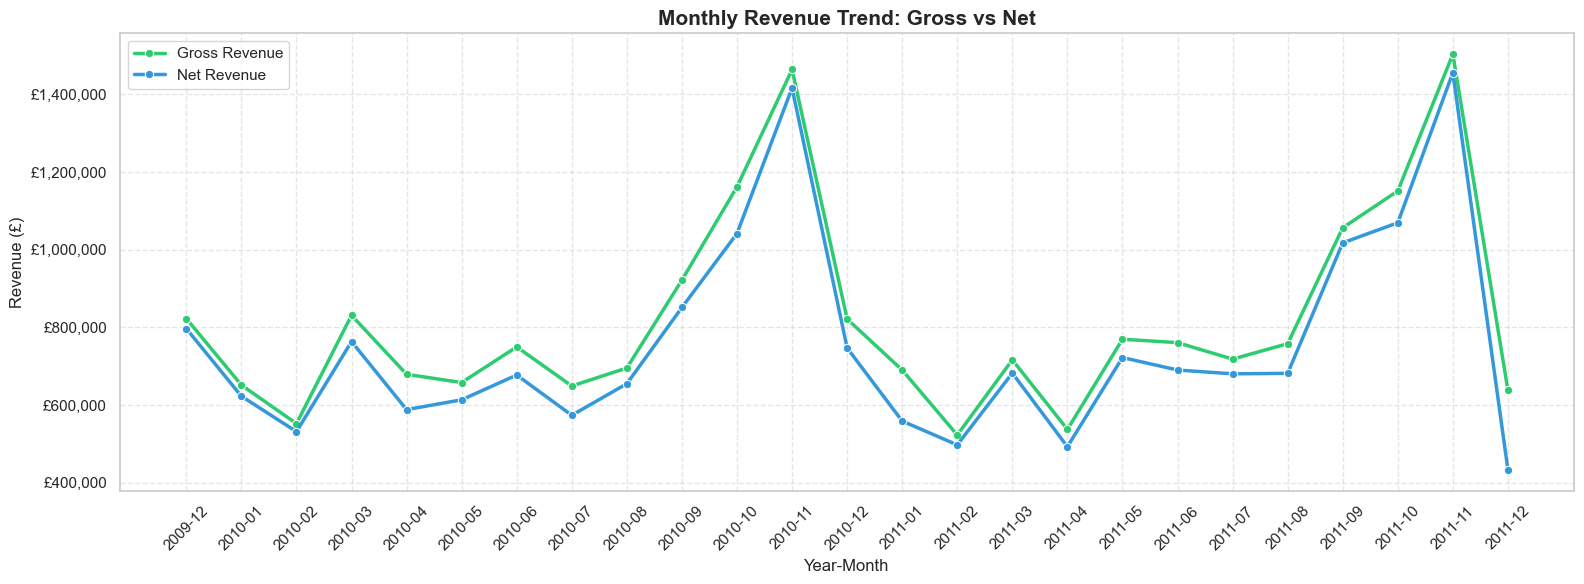

In [10]:
# --- Revenue Trend Analysis: Gross vs Net ---
gross_revenue = df[df['TotalPrice'] > 0].groupby('YearMonth')['TotalPrice'].sum().reset_index()
gross_revenue.rename(columns={'TotalPrice': 'Gross Revenue'}, inplace=True)

net_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
net_revenue.rename(columns={'TotalPrice': 'Net Revenue'}, inplace=True)

revenue_trend = pd.merge(gross_revenue, net_revenue, on='YearMonth')
revenue_melted = revenue_trend.melt(id_vars='YearMonth', value_vars=['Gross Revenue', 'Net Revenue'], var_name='Revenue Type', value_name='Amount')

plt.figure(figsize=(16, 6))
sns.lineplot(data=revenue_melted, x='YearMonth', y='Amount', hue='Revenue Type', marker='o', linewidth=2.5, palette=['#2ecc71', '#3498db'])
plt.title('Monthly Revenue Trend: Gross vs Net', fontsize=15, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'£{int(x):,}'))
plt.xticks(rotation=45)
plt.legend(title='', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Distribution Analysis & Outliers

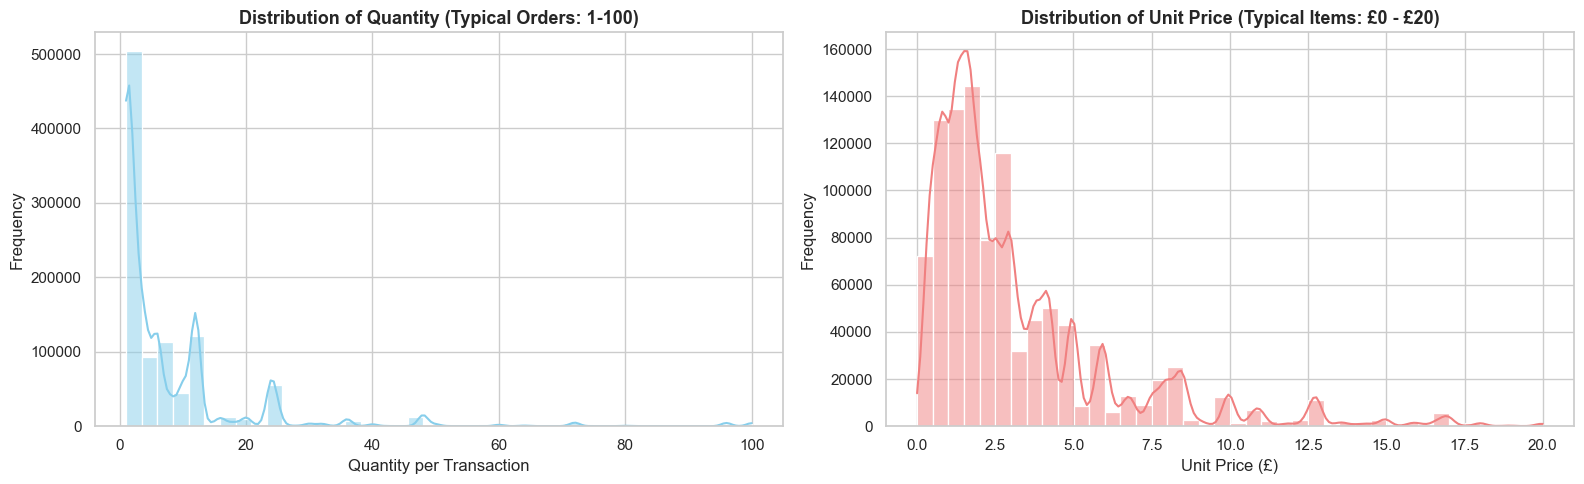

In [11]:
# --- Distribution Analysis (Histograms) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

typical_quantity = df[(df['Quantity'] > 0) & (df['Quantity'] <= 100)]['Quantity']
sns.histplot(typical_quantity, bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Quantity (Typical Orders: 1-100)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantity per Transaction')
axes[0].set_ylabel('Frequency')

typical_price = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)]['UnitPrice']
sns.histplot(typical_price, bins=40, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Unit Price (Typical Items: £0 - £20)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unit Price (£)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

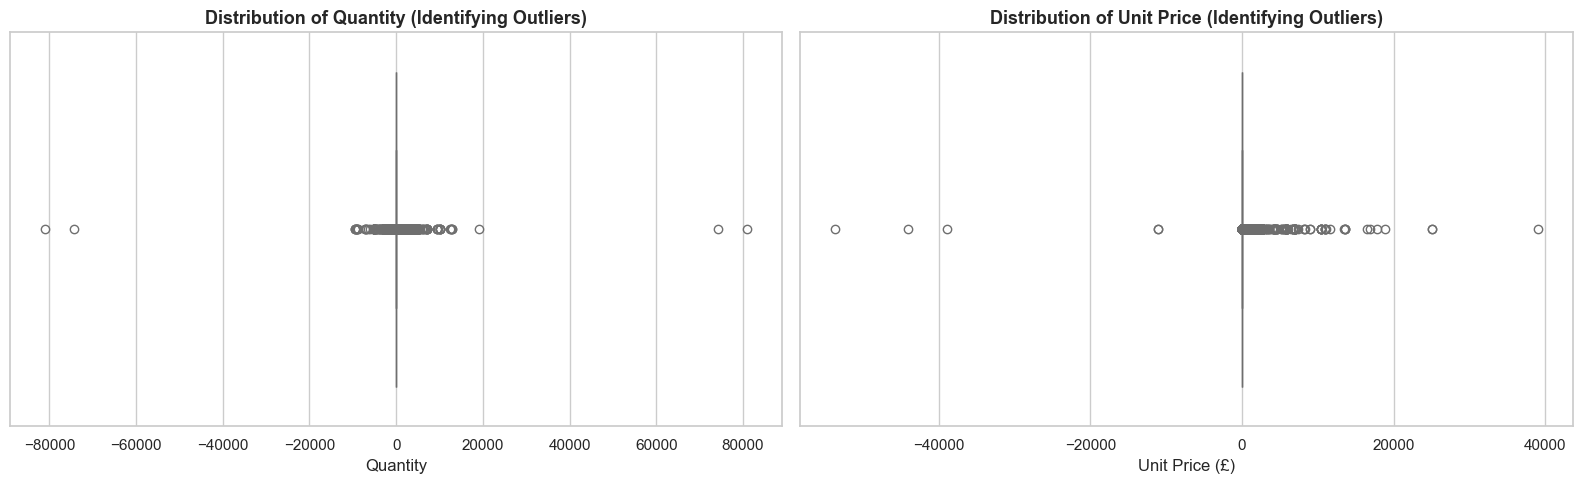

In [12]:
# --- Outlier Visualization (Boxplots Only) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=df['Quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Quantity (Identifying Outliers)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantity')

sns.boxplot(x=df['UnitPrice'], ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Unit Price (Identifying Outliers)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unit Price (£)')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

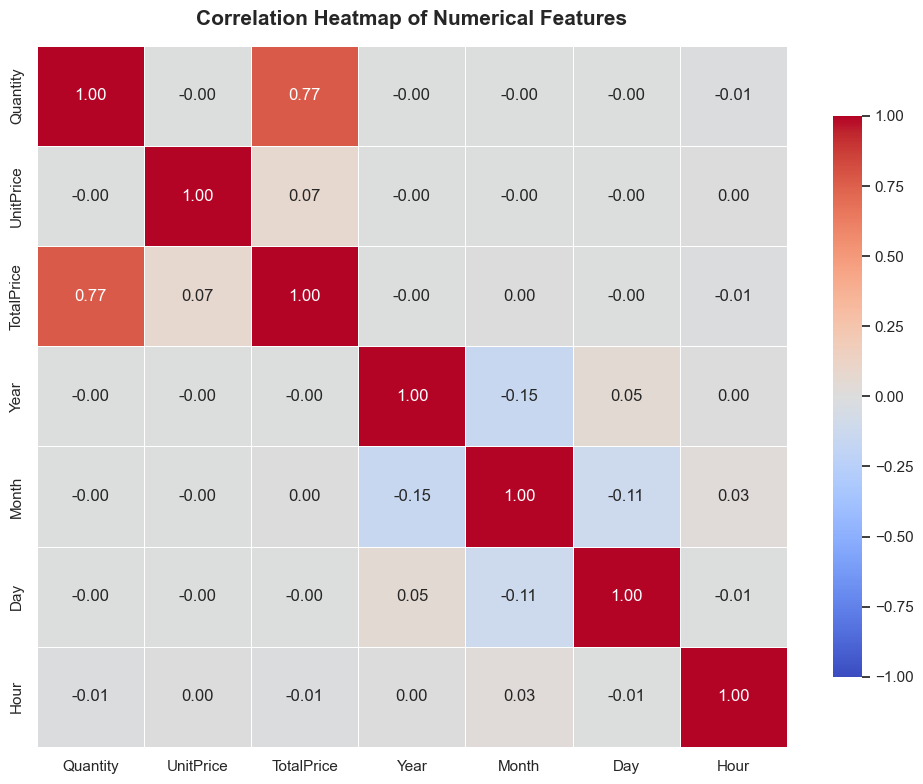

In [13]:
# --- Correlation Heatmap ---
numerical_df = df.select_dtypes(include=['float64', 'int64', 'int32']).drop(columns=['CustomerID'], errors='ignore')
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    vmin=-1, vmax=1,     
    linewidths=0.5,      
    cbar_kws={"shrink": .8} 
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 7. Save Checkpoint

In [14]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/online_retail_initial.csv', index=False)

print("Checkpoint saved: ../data/processed/online_retail_initial.csv")

Checkpoint saved: ../data/processed/online_retail_initial.csv
